# Q4: What is the ideal number of couriers?

## Imports


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## Load the data

In [2]:
fleet_path = Path("../data/clean/dc_sim_fleet_sweep.csv")
fleet_results = pd.read_csv(fleet_path)
fleet_results.head()

,strategy,fleet,mean_min,median_min,p95_min,ontime45_pct,peak19_mean_min,mean_cycle_min,utilization_pct,runtime_s
0,nac,100,592.04,532.02,1246.18,11.7,898.33,14.92,85.1,0.1
1,nac,150,287.16,261.08,605.88,13.4,421.39,14.90,76.0,0.1
2,nac,200,137.96,126.42,297.95,15.9,187.07,14.81,68.1,0.1
3,nac,300,55.12,46.62,123.40,48.3,78.24,15.34,53.0,0.1
4,nac,400,29.74,24.48,57.42,81.2,41.55,16.06,41.6,0.2


## Summarize performance at each fleet size

In [3]:
fleet_summary = (
    fleet_results.groupby("fleet")
    .agg(
        mean_delivery_min=("mean_min", "mean"),
        p95_delivery_min=("p95_min", "mean"),
        mean_ontime45_pct=("ontime45_pct", "mean"),
        min_ontime45_pct=("ontime45_pct", "min"),
        peak19_mean_min=("peak19_mean_min", "mean"),
        mean_utilization_pct=("utilization_pct", "mean"),
    )
    .reset_index()
)

display(
    fleet_summary[[
        "fleet", "mean_delivery_min", "p95_delivery_min",
        "mean_ontime45_pct", "peak19_mean_min", "mean_utilization_pct"
    ]].round(2)
)

,fleet,mean_delivery_min,p95_delivery_min,mean_ontime45_pct,peak19_mean_min,mean_utilization_pct
0,100,576.00,1211.66,11.75,873.49,84.10
1,150,279.60,589.42,13.40,409.40,74.90
2,200,133.49,288.25,16.60,180.04,67.20
3,300,54.39,121.29,48.95,77.24,51.85
4,400,29.81,56.92,81.50,41.49,40.50
5,500,21.90,30.78,100.00,24.33,34.30
6,600,20.99,29.24,99.95,21.68,30.20
7,800,20.80,28.98,99.95,21.50,23.75


## Visualize fleet size and delivery performance


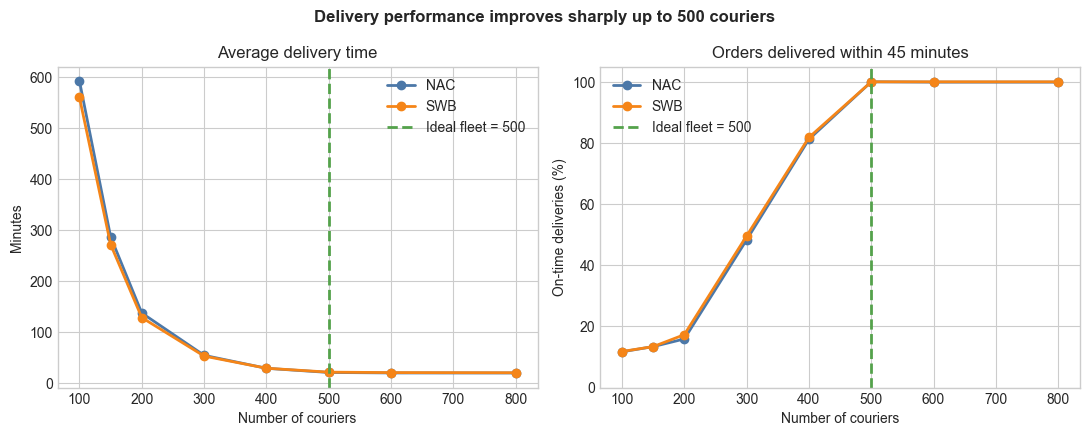

In [4]:
colors = {"nac": "#4C78A8", "swb": "#F58518"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for strategy, subset in fleet_results.groupby("strategy"):
    subset = subset.sort_values("fleet")
    axes[0].plot(
        subset["fleet"], subset["mean_min"], marker="o", linewidth=2,
        label=strategy.upper(), color=colors[strategy]
    )
    axes[1].plot(
        subset["fleet"], subset["ontime45_pct"], marker="o", linewidth=2,
        label=strategy.upper(), color=colors[strategy]
    )

for ax in axes:
    ax.axvline(500, color="#54A24B", linestyle="--", linewidth=2, label="Ideal fleet = 500")
    ax.set_xlabel("Number of couriers")
    ax.legend(frameon=False)

axes[0].set_title("Average delivery time")
axes[0].set_ylabel("Minutes")
axes[1].set_title("Orders delivered within 45 minutes")
axes[1].set_ylabel("On-time deliveries (%)")
axes[1].set_ylim(0, 105)
fig.suptitle("Delivery performance improves sharply up to 500 couriers", fontweight="bold")
fig.tight_layout()
plt.show()

## Measure the benefit of adding more couriers

Because the tested fleet-size gaps are not always equal, the improvement is standardized as minutes saved per 100 added couriers.


In [5]:
fleet_summary["next_tested_fleet"] = fleet_summary["fleet"].shift(-1)
fleet_summary["gain_to_next_fleet_min"] = (
    fleet_summary["mean_delivery_min"]
    - fleet_summary["mean_delivery_min"].shift(-1)
)
fleet_summary["gain_per_100_added"] = (
    fleet_summary["gain_to_next_fleet_min"]
    / (fleet_summary["next_tested_fleet"] - fleet_summary["fleet"])
    * 100
)

marginal = fleet_summary.dropna(subset=["gain_per_100_added"]).copy()
marginal["interval"] = (
    marginal["fleet"].astype(int).astype(str)
    + " to "
    + marginal["next_tested_fleet"].astype(int).astype(str)
)

display(
    marginal[["interval", "gain_to_next_fleet_min", "gain_per_100_added"]]
    .rename(columns={
        "interval": "fleet_increase",
        "gain_to_next_fleet_min": "total_minutes_saved",
        "gain_per_100_added": "minutes_saved_per_100",
    })
    .round(2)
)


,fleet_increase,total_minutes_saved,minutes_saved_per_100
0,100 to 150,296.40,592.80
1,150 to 200,146.12,292.24
2,200 to 300,79.10,79.10
3,300 to 400,24.58,24.58
4,400 to 500,7.91,7.91
5,500 to 600,0.91,0.91
6,600 to 800,0.19,0.09


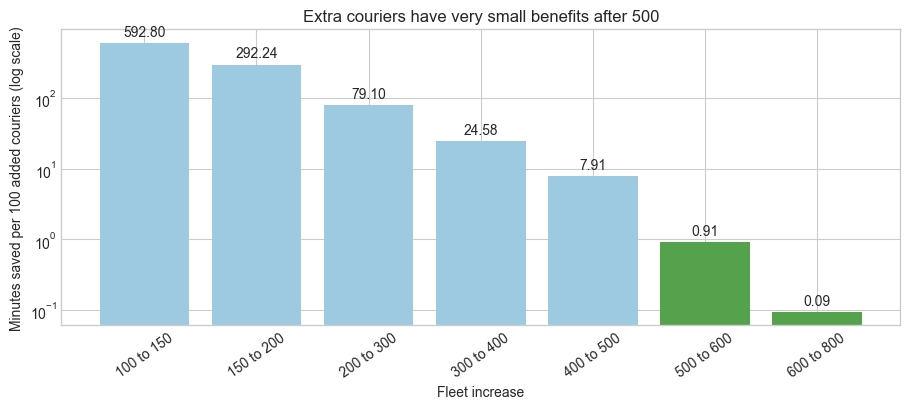

In [6]:
fig, ax = plt.subplots(figsize=(9.2, 4.2))
bar_colors = ["#54A24B" if start >= 500 else "#9ECAE1" for start in marginal["fleet"]]
bars = ax.bar(marginal["interval"], marginal["gain_per_100_added"], color=bar_colors)
ax.set_yscale("log")
ax.set_title("Extra couriers have very small benefits after 500")
ax.set_xlabel("Fleet increase")
ax.set_ylabel("Minutes saved per 100 added couriers (log scale)")
ax.tick_params(axis="x", rotation=35)
ax.bar_label(bars, labels=[f"{value:.2f}" for value in marginal["gain_per_100_added"]], padding=3)
fig.tight_layout()
plt.show()

## Select the ideal fleet size


In [7]:
candidates = fleet_summary[
    (fleet_summary["min_ontime45_pct"] >= 99.5)
    & (fleet_summary["gain_to_next_fleet_min"] < 1)
]

ideal_fleet = int(candidates.iloc[0]["fleet"])
print(f"Ideal fleet size: {ideal_fleet} couriers")

print("\nPerformance at the ideal fleet size:")
display(
    fleet_results[fleet_results["fleet"] == ideal_fleet]
    [["strategy", "mean_min", "p95_min", "ontime45_pct", "peak19_mean_min", "utilization_pct"]]
    .set_index("strategy")
    .round(2)
)

Ideal fleet size: 500 couriers

Performance at the ideal fleet size:


,mean_min,p95_min,ontime45_pct,peak19_mean_min,utilization_pct
strategy,,,,,
nac,21.59,30.43,100.0,23.85,36.3
swb,22.21,31.13,100.0,24.81,32.3


## Conclusion

The ideal tested fleet size is 500 couriers. 

Since：
- At 500 couriers, both NAC and SWB deliver 100% of orders within 45 minutes.
- Average delivery time is 21.59 minutes for NAC and 22.21 minutes for SWB.
- During the 7 PM peak, average delivery time is only 23.85–24.81 minutes.
- Increasing the fleet from 500 to 600 saves only 0.91 minute on average.
- Increasing it from 600 to 800 saves only another 0.19 minute， while average courier utilization falls from 30.2% to 23.75%.

Therefore, 500 couriers gives the best balance of fast and reliable delivery without adding many couriers for very small performance gains. NAC is slightly faster at this fleet size.